In [27]:
from FormUtils import pyForm, capture_physics_expr

In [ ]:
%%pyForm ee_inclZ_mumu

* Process: e+ e- -> mu+ mu- (EW)


* Above suppresses extra output
Off Statistics;
Off FinalStats;

#include amplitude.h

* Kinematic variables
Symbols s, t, u;

* Physical constants
Symbols e, pi, alpha, cv, ca, mZ, gweak;

* Three momenta ratio in CM
Symbols pfInOutRatio;

Local MQED = (e^2 )    * (VB(i1, p2, 0) * g(i1, i2, mu1) * U(i2, p1, 0))  
                       * phprop(mu1, mu2, q) 
                       * (UB(i3, p3, 0) * g(i3, i4, mu2) * V(i4, p4, 0));

Local MZ = (gweak^2/4) * (VB(i1, p2, 0) * g(i1, i2, mu1) * 1/2* ((cv-ca)*g(i2, i3, k7) + (cv+ca)*g(i2, i3, k6)) * U(i3, p1, 0))
                       * Zprop(mu1, mu2, q, mZ)
                       * (UB(i4, p3, 0) * g(i4, i5, mu2) * 1/2 * ((cv-ca)*g(i5, i6, k7) + (cv+ca)*g(i5, i6, k6)) * V(i6, p4, 0));
Local Mtot = MQED + MZ;

#call squareamplitude(MQED, MsqQED)
#call squareamplitude(MZ, MsqZ)
#call squareamplitude(Mtot, MsqTot)
.sort 
Local MsqInt = MsqTot - MsqQED - MsqZ;
.sort


* Spin averaging (1/2 * 1/2)
multiply 1/4; 
* coupling
id e^4 = 16 * pi^2 * alpha^2;
id e^2 = 4 * pi * alpha;
* propagator handling
id q = p1 + p2;
id prop(x?) = (x)^-1;
id (q.q)^-1 = (s)^-1;
id (-mZ^2 + q.q)^-1 = (s - mZ^2)^-1;
.sort


* Mandelstam
repeat;
* Massless limit
    id p1.p1 = 0;
    id p2.p2 = 0;
    id p3.p3 = 0;
    id p4.p4 = 0;
    
    id p1.p2 = s/2;
    id p3.p4 = s/2;
    id p1.p3 = - t/2;
    id p2.p4 = - t/2;
    id p1.p4 = u/2;
    id p2.p3 = u/2;    
endrepeat;
.sort;


Bracket s, alpha, gweak;
.sort
* Save
Format C;
#write <ee_incl_mumu_QED.txt> "%e;", MsqQED;
#write <ee_incl_mumu_Int.txt> "%e;", MsqInt;
#write <ee_incl_mumu_Z.txt> "%e;", MsqZ;
.sort

* Print
Format;
Print +s MsqZ;
Print +s MsqInt;
Print +s MsqQED;
.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Tue Apr 14 15:01:54 2026
    
    * Process: e+ e- -> mu+ mu- (EW)
    
    
    * Above suppresses extra output
    Off Statistics;
    Off FinalStats;
    
    #include amplitude_old.h
    *-------------------------------------------------------------------------*
    * amplitude.inc
    * Original from: Jos Vermaseren (NIKHEF)
    * See also : J.A.M.Vermaseren "New features of FORM" math-ph/0010025
    *
    * Core Procedure: squareamplitude 
    * Description:
    * FORM procedure for squaring Feynman amplitudes, 
    * performing spin sums, and evaluating Dirac traces.
    *-------------------------------------------------------------------------*
    
    AutoDeclare Index i,mu,k;
    AutoDeclare Symbol m,x;
    AutoDeclare Vector p,q;
    Vector q,q1,q2,p1,...,p10;
    CF  UB,U,VB,V,g,eps,epsM;
    CF  fprop,phprop,Zprop,Wprop,prop;
    Index k5=0, k6=0, k7=0;
    *
    *
    #procedure squareamplitude(Amp,Mat)
    .sort
    

Captured Expression for QED: +pow(s,-2)*pow(alpha,2)*(-32*pow(u,2)*pow(pi,2))
Captured Expression for Z : 0
Captured Expression for Int: +pow(s,-1)*alpha*pow(gweak,2)*(-2/(-pow(mZ,2)+s)*pow(u,2)*pi*pow(ca,2)-6/(-pow(mZ,2)+s)*pow(u,2)*pi*pow(cv,2))+alpha*pow(gweak,2)*(1./2./(-pow(mZ,2)+s)*pow(u,2)*pi*pow(ca,2)*pow(mZ,-2)+3./2./(-pow(mZ,2)+s)*pow(u,2)*pi*pow(cv,2)*pow(mZ,-2))
M^2 QED : -32*pi**2*alpha**2*u**2/s**2
M^2 Weak : 0
M Int: pi*alpha*gweak**2*u**2*(2*mZ**2*(ca**2 + 3*cv**2) - s*(0.5*ca**2 + 1.5*cv**2))/(mZ**2*s*(mZ**2 - s))
dsigma/dOmega CM QED =  -alpha**2*(cos(theta) + 1)**2/(8*s)
dsigma/dOmega CM Weak =  0
dsigma/dOmega CM Int =  alpha*gweak**2*(2*mZ**2*(ca**2 + 3*cv**2) - s*(0.5*ca**2 + 1.5*cv**2))*(cos(theta) + 1)**2/(256*pi*mZ**2*(mZ**2 - s))


ValueError: x and y must have same first dimension, but have shapes (100,) and (1,)

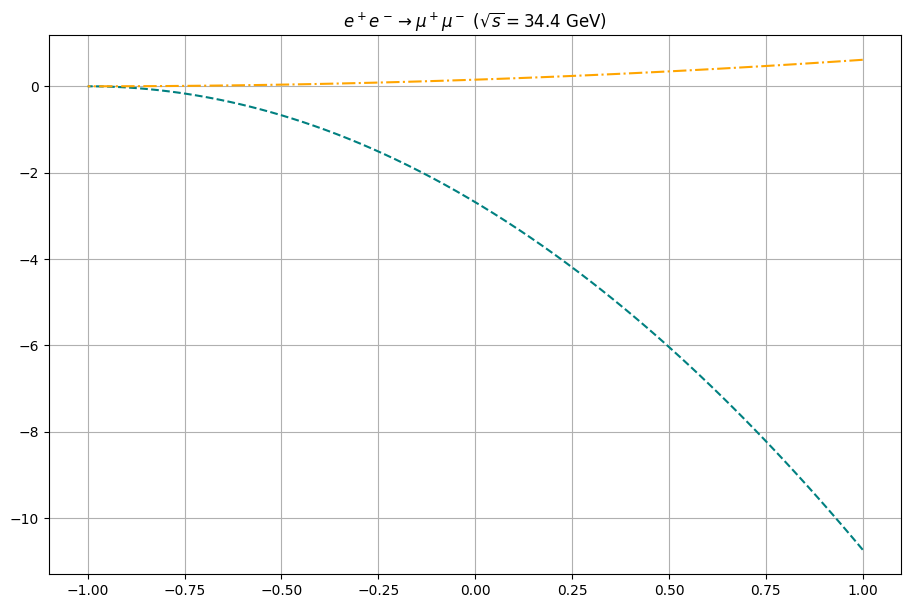

In [29]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from Kinematics import XS_2To2_CM

plt.style.use("seaborn-v0_8-muted")
plt.rcParams["axes.grid"] = True


# Capture from FORM
form_exprQED = capture_physics_expr("scripts/ee_incl_mumu_QED.txt")
print(f"Captured Expression for QED: {form_exprQED}")

form_exprZ = capture_physics_expr("scripts/ee_incl_mumu_Z.txt")
print(f"Captured Expression for Z : {form_exprZ}")

form_exprInt = capture_physics_expr("scripts/ee_incl_mumu_Int.txt")
print(f"Captured Expression for Int: {form_exprInt}")


# Simplify via sympy
alpha, gweak, mZ, s = sp.symbols("alpha gweak mZ s")
cv, ca, t, u = sp.symbols("cv ca t u")
MsqQED = sp.simplify(form_exprQED)
print(f"M^2 QED : {MsqQED }")


MsqZ = sp.simplify(form_exprZ)
print(f"M^2 Weak : {MsqZ}")


MInt = sp.simplify(form_exprInt)
print(f"M Int: {MInt }")

# Get the xs in CM
theta = sp.Symbol("theta", real=True)

xsQED = XS_2To2_CM(MsqQED, s, t, u, theta, 0, 0, 0, 0)
print(f"dsigma/dOmega CM QED =  {xsQED}")

xsZ = XS_2To2_CM(MsqZ, s, t, u, theta, 0, 0, 0, 0)
print(f"dsigma/dOmega CM Weak =  {xsZ}")

xsInt = XS_2To2_CM(MInt, s, t, u, theta, 0, 0, 0, 0)
print(f"dsigma/dOmega CM Int =  {xsInt}")

# lambdify
xsQED_lambda = sp.lambdify((s, alpha, theta), xsQED, "numpy")
xsZ_lambda = sp.lambdify((s, gweak, cv, ca, mZ, theta), xsZ, "numpy")
xsInt_lambda = sp.lambdify((s, alpha, gweak, cv, ca, mZ, theta), xsInt, "numpy")

#
sqrtS = 34.4
s_val = sqrtS * sqrtS
# Running of alpha
alpha_val = (1 / 137.036) / (
    1 - (1 / (137.036 * 3 * np.pi)) * np.log(s_val / 5.11e-4**2)
)
# Weak coupling
sin2w = 0.23122
gweak_val = np.sqrt(4 * np.pi * alpha_val) / np.sqrt(sin2w * (1 - sin2w))
#
mZ_val = 91.1876
cv_val = -0.5 + 2 * sin2w
ca_val = -0.5
#
conv_gev2_to_nb = 389379.0

# Fill values for Plotting
angles = np.linspace(0, np.pi, 100)
x_vals = np.cos(angles)


y_QED = xsQED_lambda(s_val, alpha_val, angles)
y_QED = s_val * y_QED * conv_gev2_to_nb

y_Z = xsZ_lambda(s_val, gweak_val, cv_val, ca_val, mZ_val, angles)
y_Z = (sqrtS**2) * y_Z * conv_gev2_to_nb

y_Int = xsInt_lambda(s_val, alpha_val, gweak_val, cv_val, ca_val, mZ_val, angles)
y_Int = (sqrtS**2) * y_Int * conv_gev2_to_nb

y_Total = y_QED + y_Z + y_Int

plt.figure(figsize=(11, 7))
plt.title(rf"$e^+e^- \to \mu^+\mu^-$ ($\sqrt{{s}}={(sqrtS)}$ GeV)")
plt.plot(x_vals, y_QED, label="Pure QED ", color="teal", lw=1.5, ls="--")
plt.plot(x_vals, y_Int, label="Interference ", color="orange", lw=1.5, ls="-.")
plt.plot(x_vals, y_Z, label="Pure Z ", color="crimson", lw=1.5, ls=":")
plt.plot(x_vals, y_Total, label="Total (QED + Z + Int)", color="black", lw=2.5)
plt.legend(loc="upper center", ncol=2, frameon=True, shadow=True, fontsize=10)
plt.show()